
# PINNsFormer + Adaptive M-ConFIG-4 v1：自适应梯度刷新调度 × 3 Seeds

这个 notebook 的目标已经不是“继续验证 ConFIG”，而是研究一个更具体的问题：

> **当每个 optimizer step 只允许计算 1 个 fresh task gradient 时，能不能通过更聪明的刷新调度，比 M-ConFIG 固定轮询取得更好的场重建精度与 physics convergence，同时保留低计算成本？**

当前四个 task / loss 仍然完全不变：

$$
L_{u,\mathrm{data}},\qquad
L_{v,\mathrm{data}},\qquad
L_{f_u},\qquad
L_{f_v}.
$$

对应四个参数梯度：

$$
g_u,\qquad g_v,\qquad g_{f_u},\qquad g_{f_v}.
$$

本 notebook 只比较两个低计算方法：

1. **M-ConFIG-4 Fixed Round-Robin + SGD**
   - 每 step 只刷新 1 个真实 task gradient；
   - 固定顺序：
     `u_data -> v_data -> f_u -> f_v -> ...`

2. **Adaptive M-ConFIG-4 v1 (Staleness × Gradient Drift) + SGD**
   - 每 step 同样只刷新 1 个真实 task gradient；
   - 不再固定轮询；
   - 根据“多久没刷新 + 这个 task 的梯度历史上变化有多快”动态选择。

因此最核心的公平条件是：

$$
\boxed{
N_{\mathrm{fresh}}^{\mathrm{FixedRR}}
\approx
N_{\mathrm{fresh}}^{\mathrm{Adaptive}}
=
1000
}
$$

如果 Adaptive 更好，才能把主要差异归因到 **refresh policy / scheduler**，而不是“它算了更多梯度”。



# ⭐ 核心方法：Adaptive Gradient Refresh v1

## ⭐ 这就是本 notebook 唯一新增的核心机制

可以把 M-ConFIG 中每个 task 的梯度看成一个“缓存”。

- 真正重新计算 $g_i^{\mathrm{fresh}}=\nabla_\theta L_i$ 很贵；
- M-ConFIG 内部保存历史梯度形成的 momentum estimate $\hat g_i$；
- 每个 step 只有一次真实 gradient refresh 预算；
- **scheduler 决定这一次昂贵 backward 应该花给谁。**

Fixed Round-Robin 的规则是：

$$
i_t=t\bmod4.
$$

它只看“轮到谁”，完全不看当前梯度状态。

Adaptive v1 改成：

$$
\boxed{
i_t=\arg\max_i S_i(t)
}
$$

其中 $S_i(t)$ 是 task $i$ 的刷新紧迫度。

---

## 1. Staleness：这个梯度多久没有重新计算

定义：

$$
a_i(t)=t-t_i^{\mathrm{last\ refresh}}.
$$

例如当前：

```text
u_data : age = 3
v_data : age = 1
f_u    : age = 2
f_v    : age = 0
```

它只回答：

> **“这个缓存有多旧？”**

---

## 2. Gradient Drift：这个 task 的梯度历史上变化有多快

当 task $i$ 被真正刷新时，在更新 PseudoMomentum **之前**，先比较旧估计和当前 fresh gradient：

$$
\hat g_i^{\mathrm{old}}
\quad\mathrm{vs}\quad
g_i^{\mathrm{fresh}}.
$$

定义一次 drift observation：

$$
r_i(t)
=
\frac{
1-\cos\left(\hat g_i^{\mathrm{old}},g_i^{\mathrm{fresh}}\right)
}{2}.
$$

因此理论上：

$$
r_i\in[0,1].
$$

- cosine 接近 1：旧 estimate 仍然可靠，drift 小；
- cosine 接近 0：方向已经明显变化；
- cosine < 0：旧 estimate 和当前 gradient 方向已经相反，drift 很大。

为了避免一次异常值决定后续调度，对 drift 做 EMA：

$$
d_i
\leftarrow
\rho d_i+(1-\rho)r_i.
$$

$d_i$ 表示：

> **“这个 task 最近的 gradient freshness sensitivity / 老化速度。”**

---

## 3. 刷新紧迫度：Staleness × Drift

第一版保持简单：

$$
\boxed{
S_i(t)
=
a_i(t)\left(\epsilon+d_i(t)\right)
}
$$

于是：

- **很旧但一直很稳定**的 gradient，不一定优先；
- **没那么旧但变化非常快**的 gradient，可能优先刷新。

这和缓存管理/调度问题类似：

> 有限计算预算下，不是机械轮询，而是把刷新成本优先给最容易“过期失真”的信息。

---

## 4. 防止 task 饿死：Max-Age Guard

纯 score 可能导致一个很稳定的 task 长时间不刷新。

因此增加：

$$
a_i(t)\ge A_{\max}
\Rightarrow
\text{强制优先刷新}.
$$

本 notebook 默认：

```text
MAX_AGE = 8
```

这只是 v1 的工程保护参数，不代表 8 是理论最优值。

---

## 5. 初始化阶段保持作者 M-ConFIG 语义

`PseudoMomentumOperator` 需要四个 task 至少各得到一次真实 gradient 才能形成完整状态。

因此前四步固定：

```text
step 0 -> u_data
step 1 -> v_data
step 2 -> f_u
step 3 -> f_v
```

从 step 4 才开始 Adaptive Scheduler。

---

## 6. 最重要的约束：Scheduler 自己不能偷算 fresh gradients

Adaptive 在“决定刷新谁”之前 **不能先计算四个 fresh gradients**。

否则：

```text
先算 4 个梯度
-> 再判断刷新谁
```

已经失去 M-ConFIG 降低计算量的意义。

因此 scheduler 只允许使用：

- age；
- 历史 drift EMA；
- 已有 PseudoMomentum 状态；
- 已记录的低成本历史信息。

真正的 fresh gradient 只有被选中的 task 才会计算。

---

## 7. 本轮要验证的假设

$$
\boxed{
\text{同样约 1000 次 fresh gradients，Adaptive 是否优于 Fixed RR？}
}
$$

如果 Adaptive 能做到：

- $v$ Relative L2 更低；
- strict physics threshold 更容易达到；
- update-vs-fresh nonpositive alignment 更少；
- wall time 仍接近 Fixed RR；
- fresh-gradient count 仍约 1000；

那么才说明：

> **不同 task 不需要等频率刷新，动态分配梯度计算预算具有实际价值。**



# ⭐ 核心调度伪代码

```text
输入:
    4 个 task
    每个 task 的 last_refresh_step
    每个 task 的 drift_ema
    每 step fresh-gradient budget = 1

前 4 step:
    u_data -> v_data -> f_u -> f_v
    完成 PseudoMomentum 初始化

从 step 4 开始:

    1. 计算每个 task 的 age
       age_i = step - last_refresh_i

    2. 检查 Max-Age Guard
       如果某 task age >= MAX_AGE:
           选择最旧 task
       否则:
           score_i = age_i * (EPS + drift_ema_i)
           选择 score 最大的 task

    3. 只对被选中的 task:
       loss_i -> fresh gradient g_i

    4. 更新 PseudoMomentum 前:
       old_estimate = m_hat_i
       drift_obs = (1 - cosine(old_estimate, fresh_gradient)) / 2
       drift_ema_i <- rho * drift_ema_i + (1-rho) * drift_obs

    5. 把 fresh gradient 写入 PseudoMomentumOperator

    6. 其余 3 个 task 继续使用历史 momentum estimate

    7. ConFIG 组合公共方向

    8. SGD optimizer.step()
```

**Fixed RR 与 Adaptive 的 fresh-gradient budget 完全一致；真正变化的只有第 2 步的选择规则。**


In [1]:

from pathlib import Path
import os
import sys
import time
import json
import csv
import gc
import random
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("PyTorch          :", torch.__version__)
print("CUDA runtime     :", torch.version.cuda)
print("CUDA available   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU              :", torch.cuda.get_device_name(0))


Python executable: /home/simplexity/anaconda3/envs/config_pinn/bin/python
Python version   : 3.10.21
PyTorch          : 2.5.1+cu121
CUDA runtime     : 12.1
CUDA available   : True
GPU              : NVIDIA GeForce GTX 1080 Ti


# 实验配置

In [2]:

PINNSFORMER_ROOT = Path(
    os.environ.get("PINNSFORMER_ROOT", "/home/simplexity/cyt/pinnsformer-main")
)

EXPERIMENT_ROOT = Path(
    os.environ.get(
        "PINNSFORMER_CONFIG_ROOT",
        str(PINNSFORMER_ROOT / "pinnsformer-config"),
    )
)

CONFIG_ROOT = Path(
    os.environ.get("CONFIG_ROOT", "/home/simplexity/cyt/ConFIG-main")
)

DATA_PATH = (
    PINNSFORMER_ROOT
    / "demo"
    / "navier_stokes"
    / "cylinder_nektar_wake.mat"
)

# 上一轮 Full-Refresh / Fixed-RR 结果，仅用于最后上下文读取。
PREVIOUS_MCONFIG_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "navier_stokes_mconfig4_fixed_roundrobin"
)

OUTPUT_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "navier_stokes_adaptive_mconfig4_v1"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_SEEDS = [0, 1, 2]
FORCE_RERUN = False

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

N_TRAIN = 800
NUM_STEP = 5
TIME_STEP = 1e-2
EPOCHS = 1000
SNAPSHOT = 100

SGD_LR = 1e-4
BETA_1 = 0.9
BETA_2 = 0.999

LOSS_KEYS = ["u_data", "v_data", "f_u", "f_v"]
LOSS_INDEX = {name: i for i, name in enumerate(LOSS_KEYS)}

METHODS = [
    # "mconfig4_fixed_roundrobin",
    "adaptive_mconfig4_age_drift_v1",
]

# ===== Adaptive Scheduler v1 =====
DRIFT_EMA_RHO = 0.80
DRIFT_INIT = 0.25
SCORE_EPS = 0.05
MAX_AGE = 8

# metric 只测 loss，不改变训练状态。
METRIC_INTERVAL = 10

# 37 与 Fixed RR 周期 4 互质，避免上一版 interval=50 的 phase aliasing。
PROBE_INTERVAL = 37

PHYSICS_THRESHOLDS = [1e-2, 5e-3, 2e-3, 1e-3, 5e-4]

print("PINNSFORMER_ROOT :", PINNSFORMER_ROOT)
print("EXPERIMENT_ROOT  :", EXPERIMENT_ROOT)
print("CONFIG_ROOT      :", CONFIG_ROOT)
print("DATA_PATH        :", DATA_PATH)
print("OUTPUT_ROOT      :", OUTPUT_ROOT)
print("DEVICE           :", DEVICE)
print("RUN_SEEDS        :", RUN_SEEDS)
print()
print("Adaptive v1:")
print("  DRIFT_EMA_RHO =", DRIFT_EMA_RHO)
print("  DRIFT_INIT    =", DRIFT_INIT)
print("  SCORE_EPS     =", SCORE_EPS)
print("  MAX_AGE       =", MAX_AGE)
print("  PROBE_INTERVAL=", PROBE_INTERVAL)


PINNSFORMER_ROOT : /home/simplexity/cyt/pinnsformer-main
EXPERIMENT_ROOT  : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config
CONFIG_ROOT      : /home/simplexity/cyt/ConFIG-main
DATA_PATH        : /home/simplexity/cyt/pinnsformer-main/demo/navier_stokes/cylinder_nektar_wake.mat
OUTPUT_ROOT      : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adaptive_mconfig4_v1
DEVICE           : cuda:0
RUN_SEEDS        : [0, 1, 2]

Adaptive v1:
  DRIFT_EMA_RHO = 0.8
  DRIFT_INIT    = 0.25
  SCORE_EPS     = 0.05
  MAX_AGE       = 8
  PROBE_INTERVAL= 37



## 参数边界

`DRIFT_EMA_RHO / DRIFT_INIT / SCORE_EPS / MAX_AGE` 是第一版 scheduler 的工程超参数。

当前不要因为单 seed 最优就大规模调参。推荐顺序：

1. 先用默认值完成 seed=0 smoke run；
2. 若训练稳定，再完成 0/1/2；
3. 第一版主要验证“adaptive policy 是否有信号”，不是搜索最优 scheduler；
4. 如果 v1 有收益，再做 scheduler ablation / sensitivity。


# 导入当前 PINNsFormer / ConFIG 实现

In [3]:

assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH}"
assert (EXPERIMENT_ROOT / "navier_stokes_common.py").exists()
assert (EXPERIMENT_ROOT / "gradient_diagnostics.py").exists()
assert CONFIG_ROOT.exists(), f"Missing ConFIG repo: {CONFIG_ROOT}"

sys.path.insert(0, str(EXPERIMENT_ROOT))
sys.path.insert(0, str(CONFIG_ROOT))

from navier_stokes_common import (
    PINNsformer,
    init_weights,
    get_n_params,
    load_training_data,
    compute_ns_losses,
    evaluation_tensors,
)
from gradient_diagnostics import gradient_vector, cosine_similarity

from conflictfree.grad_operator import ConFIGOperator
from conflictfree.momentum_operator import PseudoMomentumOperator
from conflictfree.utils import apply_gradient_vector_para_based

import conflictfree
print("conflictfree:", conflictfree.__file__)


conflictfree: /home/simplexity/cyt/ConFIG-main/conflictfree/__init__.py


# 通用工具

In [4]:

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def write_rows(path, rows, fieldnames=None):
    rows = list(rows)
    if not rows:
        return
    if fieldnames is None:
        fieldnames = list(rows[0].keys())
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def read_rows(path):
    with Path(path).open("r", newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def safe_mean(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(arr.mean()) if len(arr) else float("nan")


def safe_std(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) <= 1:
        return float("nan")
    return float(arr.std(ddof=1))


def relative_l2(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(
        np.linalg.norm(y_true - y_pred)
        / (np.linalg.norm(y_true) + 1e-12)
    )


def mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))


def max_abs_error(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.max(np.abs(y_true - y_pred)))


def align_pressure_mean(p_true, p_pred):
    p_true = np.asarray(p_true).reshape(-1)
    p_pred = np.asarray(p_pred).reshape(-1)
    return p_pred - np.mean(p_pred) + np.mean(p_true)


def model_name(method):
    return {
        "mconfig4_fixed_roundrobin":
            "M-ConFIG-4 Fixed RR + SGD",
        "adaptive_mconfig4_age_drift_v1":
            "Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD",
    }[method]


def make_model(device):
    model = PINNsformer(
        d_out=2,
        d_hidden=512,
        d_model=32,
        N=1,
        heads=2,
    ).to(device)
    model.apply(init_weights)
    return model



# 四个 task 的真实单项 loss

为了保持 M-ConFIG 的真实低计算语义，Fixed RR 和 Adaptive 都不能每一步先把完整四项 PDE loss 全部构造出来。

下面实现：

- `u_data`：只构造 $u$ 数据监督；
- `v_data`：只构造 $v$ 数据监督；
- `f_u`：只构造第一条 NS momentum residual；
- `f_v`：只构造第二条 NS momentum residual。

正式运行前会和统一 `compute_ns_losses()` 做 smoke test。


In [5]:

def _psi_pressure(model, x, y, t):
    out = model(x, y, t)
    return out[:, :, 0:1], out[:, :, 1:2]


def compute_single_task_loss(model, batch, task_name):
    x = batch["x"]
    y = batch["y"]
    t = batch["t"]
    u_obs = batch["u"]
    v_obs = batch["v"]

    psi, pressure = _psi_pressure(model, x, y, t)

    if task_name == "u_data":
        u_pred = torch.autograd.grad(
            psi, y,
            grad_outputs=torch.ones_like(psi),
            retain_graph=True,
            create_graph=True,
        )[0]
        return torch.mean((u_pred[:, 0] - u_obs) ** 2)

    if task_name == "v_data":
        v_pred = -torch.autograd.grad(
            psi, x,
            grad_outputs=torch.ones_like(psi),
            retain_graph=True,
            create_graph=True,
        )[0]
        return torch.mean((v_pred[:, 0] - v_obs) ** 2)

    u_pred = torch.autograd.grad(
        psi, y,
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=True,
    )[0]
    v_pred = -torch.autograd.grad(
        psi, x,
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=True,
    )[0]

    if task_name == "f_u":
        u_t = torch.autograd.grad(
            u_pred, t,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_x = torch.autograd.grad(
            u_pred, x,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_y = torch.autograd.grad(
            u_pred, y,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_yy = torch.autograd.grad(
            u_y, y,
            grad_outputs=torch.ones_like(u_y),
            retain_graph=True,
            create_graph=True,
        )[0]
        p_x = torch.autograd.grad(
            pressure, x,
            grad_outputs=torch.ones_like(pressure),
            retain_graph=True,
            create_graph=True,
        )[0]

        f_u = (
            u_t
            + (u_pred * u_x + v_pred * u_y)
            + p_x
            - 0.01 * (u_xx + u_yy)
        )
        return torch.mean(f_u ** 2)

    if task_name == "f_v":
        v_t = torch.autograd.grad(
            v_pred, t,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_x = torch.autograd.grad(
            v_pred, x,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_y = torch.autograd.grad(
            v_pred, y,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_xx = torch.autograd.grad(
            v_x, x,
            grad_outputs=torch.ones_like(v_x),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_yy = torch.autograd.grad(
            v_y, y,
            grad_outputs=torch.ones_like(v_y),
            retain_graph=True,
            create_graph=True,
        )[0]
        p_y = torch.autograd.grad(
            pressure, y,
            grad_outputs=torch.ones_like(pressure),
            retain_graph=True,
            create_graph=True,
        )[0]

        f_v = (
            v_t
            + (u_pred * v_x + v_pred * v_y)
            + p_y
            - 0.01 * (v_xx + v_yy)
        )
        return torch.mean(f_v ** 2)

    raise ValueError(f"Unknown task: {task_name}")


# Smoke Test：单 task loss / gradient 与公共实现保持一致

In [6]:

RUN_IMPLEMENTATION_SMOKE_TEST = True
SMOKE_N = 32

if RUN_IMPLEMENTATION_SMOKE_TEST:
    device = torch.device(DEVICE)

    set_seed(123)
    smoke_batch, _ = load_training_data(
        DATA_PATH,
        device,
        seed=123,
        n_train=SMOKE_N,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    set_seed(123)
    smoke_model = make_model(device)

    full_losses = compute_ns_losses(
        smoke_model,
        smoke_batch["x"],
        smoke_batch["y"],
        smoke_batch["t"],
        smoke_batch["u"],
        smoke_batch["v"],
    )

    full_values = {
        key: float(full_losses[key].detach())
        for key in LOSS_KEYS
    }

    full_grads = {}
    for i, key in enumerate(LOSS_KEYS):
        full_grads[key] = gradient_vector(
            full_losses[key],
            smoke_model,
            retain_graph=(i < len(LOSS_KEYS) - 1),
        )

    del full_losses
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    rows = []
    for key in LOSS_KEYS:
        loss_i = compute_single_task_loss(
            smoke_model,
            smoke_batch,
            key,
        )
        grad_i = gradient_vector(
            loss_i,
            smoke_model,
            retain_graph=False,
        )

        ref_loss = full_values[key]
        cur_loss = float(loss_i.detach())

        rel_loss_diff = (
            abs(cur_loss - ref_loss)
            / max(abs(ref_loss), 1e-12)
        )
        grad_cos = cosine_similarity(
            grad_i,
            full_grads[key],
        )
        grad_rel_err = float(
            (grad_i - full_grads[key]).norm()
            / (full_grads[key].norm() + 1e-12)
        )

        rows.append({
            "task": key,
            "relative_loss_diff": rel_loss_diff,
            "gradient_cosine": grad_cos,
            "gradient_relative_error": grad_rel_err,
        })

        del loss_i, grad_i

    for row in rows:
        print(row)

    assert max(r["relative_loss_diff"] for r in rows) < 1e-5
    assert min(r["gradient_cosine"] for r in rows) > 0.9999

    del smoke_model, smoke_batch, full_grads
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Smoke test passed.")
else:
    print("Smoke test skipped.")


{'task': 'u_data', 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0000001192092896, 'gradient_relative_error': 0.0}
{'task': 'v_data', 'relative_loss_diff': 0.0, 'gradient_cosine': 0.9999998807907104, 'gradient_relative_error': 0.0}
{'task': 'f_u', 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0000001192092896, 'gradient_relative_error': 9.120757482605768e-08}
{'task': 'f_v', 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0, 'gradient_relative_error': 1.1199768579217562e-07}
Smoke test passed.


# PseudoMomentum 状态工具

In [7]:

def make_momentum_operator():
    return PseudoMomentumOperator(
        num_vectors=len(LOSS_KEYS),
        beta_1=BETA_1,
        beta_2=BETA_2,
        gradient_operator=ConFIGOperator(),
    )


def get_bias_corrected_m_hats(operator):
    if operator.m is None:
        return None

    estimates = []
    for i in range(operator.num_vectors):
        count = operator.t_grads[i]
        if count <= 0:
            estimates.append(None)
        else:
            estimates.append(
                operator.m[i]
                / (1 - operator.beta_1 ** count)
            )
    return estimates


def cosine_or_nan(a, b):
    if a is None or b is None:
        return float("nan")
    return cosine_similarity(a, b)


def current_ages_before_refresh(step, last_refresh_step):
    ages = []
    for last in last_refresh_step:
        if last < 0:
            ages.append(float("inf"))
        else:
            ages.append(float(step - last))
    return ages



# ⭐⭐⭐ 核心调度算法代码：`choose_refresh_task`

下面这个函数就是 **Adaptive v1 最核心的代码**。

除了 warm-up / starvation guard，真正的自适应决策只有：

$$
S_i=a_i(\epsilon+d_i)
$$

然后：

$$
i_t=\arg\max_i S_i.
$$

### 为什么先写成这么简单？

因为第一版要回答的是：

> **“只把固定轮询换成基于 freshness risk 的动态选择，是否就能改善 Fixed RR？”**

暂时不加入：

- cached conflict；
- loss plateau；
- per-task backward cost；
- dynamic 2-loss / 4-loss grouping；
- NTK；
- learned scheduler。

这样实验如果变好，因果解释最清楚。


In [8]:

# ================================================================
# ⭐ CORE SCHEDULER: Adaptive Gradient Refresh v1
# ================================================================

def choose_refresh_task(
    *,
    step,
    last_refresh_step,
    drift_ema,
    method,
):
    # ------------------------------------------------------------
    # A. 前 4 步：必须各初始化一个 task
    # ------------------------------------------------------------
    if step < len(LOSS_KEYS):
        idx = step
        ages = current_ages_before_refresh(
            step,
            last_refresh_step,
        )
        scores = [np.nan] * len(LOSS_KEYS)
        return idx, {
            "reason": "warmup_init",
            "ages": ages,
            "scores": scores,
        }

    # ------------------------------------------------------------
    # B. Fixed RR control：唯一规则就是 step % 4
    # ------------------------------------------------------------
    if method == "mconfig4_fixed_roundrobin":
        idx = step % len(LOSS_KEYS)
        ages = current_ages_before_refresh(
            step,
            last_refresh_step,
        )
        scores = [np.nan] * len(LOSS_KEYS)
        return idx, {
            "reason": "fixed_round_robin",
            "ages": ages,
            "scores": scores,
        }

    # ------------------------------------------------------------
    # C. Adaptive v1
    # ------------------------------------------------------------
    if method == "adaptive_mconfig4_age_drift_v1":
        ages = current_ages_before_refresh(
            step,
            last_refresh_step,
        )

        finite_ages = np.asarray(ages, dtype=float)
        drift = np.asarray(drift_ema, dtype=float)

        # ⭐ 核心公式：
        # score_i = staleness_i * (epsilon + drift_i)
        scores = finite_ages * (SCORE_EPS + drift)

        # --------------------------------------------------------
        # C1. Max-Age Guard：防止长期不刷新
        # --------------------------------------------------------
        overdue = [
            i
            for i, age in enumerate(finite_ages)
            if age >= MAX_AGE
        ]

        if overdue:
            # 先选 age 最大的；若 age 相同，再选 score 最大的；
            # 最后 index 只用于稳定 tie-break。
            idx = max(
                overdue,
                key=lambda i: (
                    finite_ages[i],
                    scores[i],
                    -i,
                ),
            )
            reason = "max_age_guard"

        # --------------------------------------------------------
        # C2. 正常 Adaptive：选择 score 最大者
        # --------------------------------------------------------
        else:
            idx = int(np.argmax(scores))
            reason = "adaptive_age_x_drift"

        return idx, {
            "reason": reason,
            "ages": ages,
            "scores": scores.tolist(),
        }

    raise ValueError(f"Unknown method: {method}")



# ⭐ Gradient Drift 更新代码

注意顺序：

```text
当前 old m_hat
      ↓
计算 selected task fresh gradient
      ↓
比较 old estimate vs fresh gradient
      ↓
得到 drift observation
      ↓
更新 drift EMA
      ↓
最后才把 fresh gradient 写入 PseudoMomentumOperator
```

如果先更新 operator 再比较，就会产生信息泄漏：

> 你拿“已经包含当前 fresh gradient 的 estimate”去和当前 gradient 比，自然会显得更接近。

所以这里必须使用 **refresh 之前的 old estimate**。


In [9]:

def observe_and_update_drift(
    *,
    selected_index,
    fresh_gradient,
    operator,
    drift_ema,
):
    m_hats_before = get_bias_corrected_m_hats(operator)

    if (
        m_hats_before is None
        or m_hats_before[selected_index] is None
    ):
        return {
            "old_estimate_fresh_cosine": np.nan,
            "drift_observation": np.nan,
            "relative_estimate_error": np.nan,
            "old_estimate": None,
        }

    old_estimate = m_hats_before[selected_index]

    cos_value = cosine_similarity(
        old_estimate,
        fresh_gradient,
    )

    # cosine in [-1,1] -> drift observation in [0,1]
    drift_obs = float(
        np.clip((1.0 - cos_value) / 2.0, 0.0, 1.0)
    )

    rel_error = float(
        (old_estimate - fresh_gradient).norm()
        / (fresh_gradient.norm() + 1e-12)
    )

    drift_ema[selected_index] = (
        DRIFT_EMA_RHO * drift_ema[selected_index]
        + (1.0 - DRIFT_EMA_RHO) * drift_obs
    )

    return {
        "old_estimate_fresh_cosine": cos_value,
        "drift_observation": drift_obs,
        "relative_estimate_error": rel_error,
        "old_estimate": old_estimate,
    }


# 完整 loss / fresh-gradient probe

In [10]:

def full_loss_values_and_optional_grads(
    model,
    batch,
    *,
    need_grads=False,
):
    losses = compute_ns_losses(
        model,
        batch["x"],
        batch["y"],
        batch["t"],
        batch["u"],
        batch["v"],
    )

    values = {
        key: float(losses[key].detach())
        for key in [
            "total",
            "data",
            "physics",
            "u_data",
            "v_data",
            "f_u",
            "f_v",
        ]
    }

    fresh_grads = None

    if need_grads:
        fresh_grads = {}
        for i, key in enumerate(LOSS_KEYS):
            fresh_grads[key] = gradient_vector(
                losses[key],
                model,
                retain_graph=(i < len(LOSS_KEYS) - 1),
            )

    del losses
    return values, fresh_grads



## 为什么 `PROBE_INTERVAL=37`

上一轮 Fixed RR 使用 4-step 周期，而 probe 每 50 step 一次：

$$
\gcd(50,4)=2,
$$

会导致 probe 只反复命中部分 round-robin phase。

本版改成：

```text
PROBE_INTERVAL = 37
```

因为：

$$
\gcd(37,4)=1.
$$

这样 Fixed RR 的 probe 会逐步覆盖 4 个 phase。

Probe 中额外计算的 4 个 fresh gradients：

- **只用于诊断**；
- 不写入 PseudoMomentum；
- 不改变 scheduler；
- 不计入训练算法的 `true_task_gradient_refreshes`；
- 诊断耗时单独扣除。


# Evaluation：保持与前面实验一致

In [11]:

def evaluation_truth(reference, device):
    ev, truth_raw = evaluation_tensors(
        reference,
        device,
        snap=SNAPSHOT,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    truth = {
        name: np.asarray(value).reshape(-1)
        for name, value in truth_raw.items()
    }
    return ev, truth


def predict_fields(model, ev):
    psi_p = model(
        ev["x"],
        ev["y"],
        ev["t"],
    )

    psi = psi_p[:, :, 0:1]
    p_pred = psi_p[:, :, 1:2]

    u_pred = torch.autograd.grad(
        psi,
        ev["y"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=False,
    )[0]

    v_pred = -torch.autograd.grad(
        psi,
        ev["x"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=False,
        create_graph=False,
    )[0]

    return {
        "u": u_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "v": v_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "p": p_pred.detach().cpu().numpy()[:, 0].reshape(-1),
    }


def field_metric_rows(seed, method, truth, pred):
    rows = []

    for field in ["u", "v", "p"]:
        row = {
            "seed": int(seed),
            "method": model_name(method),
            "field": field,
            "relative_l2": relative_l2(
                truth[field],
                pred[field],
            ),
            "mae": mae(
                truth[field],
                pred[field],
            ),
            "max_absolute_error": max_abs_error(
                truth[field],
                pred[field],
            ),
            "mean_aligned_relative_l2": "",
        }

        if field == "p":
            p_aligned = align_pressure_mean(
                truth["p"],
                pred["p"],
            )
            row["mean_aligned_relative_l2"] = relative_l2(
                truth["p"],
                p_aligned,
            )

        rows.append(row)

    return rows


# Probe：update 相对当前 fresh gradients 是否仍安全

In [12]:

def pairwise_fresh_cosines(fresh_grads):
    out = {}
    for i in range(len(LOSS_KEYS)):
        for j in range(i + 1, len(LOSS_KEYS)):
            a = LOSS_KEYS[i]
            b = LOSS_KEYS[j]
            out[f"fresh_cos_{a}__{b}"] = cosine_similarity(
                fresh_grads[a],
                fresh_grads[b],
            )
    return out


def build_probe_row(
    *,
    seed,
    method,
    step,
    selected_index,
    operator,
    last_refresh_step,
    drift_ema,
    g_update,
    fresh_grads,
    full_values,
    algorithm_elapsed_s,
):
    # 注意：这里是 selected task 已完成本 step refresh 之后的 operator 状态。
    m_hats = get_bias_corrected_m_hats(operator)

    post_ages = []
    for last in last_refresh_step:
        post_ages.append(
            np.nan if last < 0 else float(step - last)
        )

    row = {
        "seed": int(seed),
        "method": model_name(method),
        "step": int(step),
        "selected_index": int(selected_index),
        "selected_task": LOSS_KEYS[selected_index],
        "algorithm_elapsed_s": float(algorithm_elapsed_s),
        **full_values,
    }

    for i, key in enumerate(LOSS_KEYS):
        estimate = (
            None
            if m_hats is None
            else m_hats[i]
        )
        fresh = fresh_grads[key]

        row[f"post_age_{key}"] = post_ages[i]
        row[f"drift_ema_{key}"] = float(drift_ema[i])
        row[f"cos_estimate_fresh_{key}"] = cosine_or_nan(
            estimate,
            fresh,
        )
        row[f"cos_update_fresh_{key}"] = cosine_or_nan(
            g_update,
            fresh,
        )

    update_cos = np.asarray(
        [
            row[f"cos_update_fresh_{key}"]
            for key in LOSS_KEYS
        ],
        dtype=float,
    )
    valid = update_cos[np.isfinite(update_cos)]

    row["min_update_fresh_alignment"] = (
        float(valid.min()) if len(valid) else np.nan
    )
    row["mean_update_fresh_alignment"] = (
        float(valid.mean()) if len(valid) else np.nan
    )
    row["nonpositive_update_fresh_rate"] = (
        float(np.mean(valid <= 0))
        if len(valid)
        else np.nan
    )

    row.update(pairwise_fresh_cosines(fresh_grads))
    return row



# ⭐ 训练核心：Scheduler 如何进入 M-ConFIG

每个 step 的执行顺序固定为：

```text
scheduler
   ↓
选出 1 个 task
   ↓
只计算这个 task 的 loss + fresh gradient
   ↓
用 old estimate 与 fresh gradient 更新 drift EMA
   ↓
PseudoMomentumOperator 写入 fresh gradient
   ↓
ConFIG 根据当前四个 momentum estimates 构造方向
   ↓
SGD step
```

**Fixed RR 和 Adaptive 的训练主干完全一致，只有 scheduler 的选择逻辑不同。**


In [13]:

def train_one_method(
    seed,
    method,
    batch,
    output_dir,
    device,
):
    output_dir = ensure_dir(output_dir)

    # 同 seed 的不同方法使用同样模型初始化规则。
    set_seed(seed)
    model = make_model(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=SGD_LR,
    )
    operator = make_momentum_operator()

    last_refresh_step = [-1] * len(LOSS_KEYS)
    drift_ema = [DRIFT_INIT] * len(LOSS_KEYS)

    scheduler_history = []
    metric_history = []
    probe_history = []

    refresh_counts = {
        key: 0
        for key in LOSS_KEYS
    }

    true_task_gradient_refreshes = 0
    probe_task_gradient_evaluations = 0
    effective_nonzero_parameter_updates = 0

    diagnostic_time_s = 0.0
    scheduler_time_s = 0.0

    max_core_peak_mib = 0.0
    max_observed_peak_mib = 0.0

    print()
    print("=" * 100)
    print(f"seed={seed} | {model_name(method)}")
    print("=" * 100)
    print("params:", get_n_params(model))

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    sync_cuda()
    wall_start = time.perf_counter()

    for step in tqdm(
        range(EPOCHS),
        desc=f"{method} seed={seed}",
    ):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        # ========================================================
        # 1. ⭐ SCHEDULER：本 step 刷新谁？
        # ========================================================

        scheduler_start = time.perf_counter()

        selected_index, scheduler_info = choose_refresh_task(
            step=step,
            last_refresh_step=last_refresh_step,
            drift_ema=drift_ema,
            method=method,
        )

        scheduler_time_s += (
            time.perf_counter() - scheduler_start
        )

        selected_task = LOSS_KEYS[selected_index]

        ages_before = scheduler_info["ages"]
        scores_before = scheduler_info["scores"]
        drift_before = list(drift_ema)

        # ========================================================
        # 2. 只计算被选中的 1 个真实 task gradient
        # ========================================================

        selected_loss = compute_single_task_loss(
            model,
            batch,
            selected_task,
        )

        selected_grad = gradient_vector(
            selected_loss,
            model,
            retain_graph=False,
        )

        true_task_gradient_refreshes += 1
        refresh_counts[selected_task] += 1

        # ========================================================
        # 3. ⭐ 在写入 PseudoMomentum 前，测 old estimate -> fresh drift
        # ========================================================

        drift_info = observe_and_update_drift(
            selected_index=selected_index,
            fresh_gradient=selected_grad,
            operator=operator,
            drift_ema=drift_ema,
        )

        # ========================================================
        # 4. PseudoMomentum + ConFIG
        # ========================================================

        g_update = operator.calculate_gradient(
            selected_index,
            selected_grad,
        )

        last_refresh_step[selected_index] = step

        scheduler_row = {
            "seed": int(seed),
            "method": model_name(method),
            "step": int(step),
            "selected_index": int(selected_index),
            "selected_task": selected_task,
            "selection_reason": scheduler_info["reason"],
            "selected_loss_value": float(selected_loss.detach()),
            "old_estimate_fresh_cosine":
                drift_info["old_estimate_fresh_cosine"],
            "drift_observation":
                drift_info["drift_observation"],
            "relative_estimate_error":
                drift_info["relative_estimate_error"],
        }

        for i, key in enumerate(LOSS_KEYS):
            scheduler_row[f"age_before_{key}"] = ages_before[i]
            scheduler_row[f"drift_before_{key}"] = drift_before[i]
            scheduler_row[f"score_before_{key}"] = scores_before[i]
            scheduler_row[f"drift_after_{key}"] = drift_ema[i]

        scheduler_history.append(scheduler_row)

        if torch.cuda.is_available():
            core_peak_pre = (
                torch.cuda.max_memory_allocated(device)
                / 1024**2
            )
            max_core_peak_mib = max(
                max_core_peak_mib,
                core_peak_pre,
            )
        else:
            core_peak_pre = np.nan

        # ========================================================
        # 5. Diagnostics：不改变训练状态
        # ========================================================

        is_metric = (
            step % METRIC_INTERVAL == 0
            or step == EPOCHS - 1
        )
        is_probe = (
            step % PROBE_INTERVAL == 0
            or step == EPOCHS - 1
        )

        if is_metric or is_probe:
            sync_cuda()
            diag_start = time.perf_counter()

            full_values, fresh_grads = (
                full_loss_values_and_optional_grads(
                    model,
                    batch,
                    need_grads=is_probe,
                )
            )

            if is_probe:
                probe_task_gradient_evaluations += len(LOSS_KEYS)

            sync_cuda()
            diag_elapsed = (
                time.perf_counter() - diag_start
            )
            diagnostic_time_s += diag_elapsed

            elapsed_wall = (
                time.perf_counter() - wall_start
            )
            algorithm_elapsed_s = max(
                0.0,
                elapsed_wall - diagnostic_time_s,
            )

            if is_metric:
                metric_history.append({
                    "seed": int(seed),
                    "method": model_name(method),
                    "step": int(step),
                    "selected_task": selected_task,
                    "algorithm_elapsed_s":
                        float(algorithm_elapsed_s),
                    "lr":
                        float(optimizer.param_groups[0]["lr"]),
                    **full_values,
                })

            if is_probe:
                probe_history.append(
                    build_probe_row(
                        seed=seed,
                        method=method,
                        step=step,
                        selected_index=selected_index,
                        operator=operator,
                        last_refresh_step=last_refresh_step,
                        drift_ema=drift_ema,
                        g_update=g_update,
                        fresh_grads=fresh_grads,
                        full_values=full_values,
                        algorithm_elapsed_s=algorithm_elapsed_s,
                    )
                )

            if torch.cuda.is_available():
                observed_peak = (
                    torch.cuda.max_memory_allocated(device)
                    / 1024**2
                )
                max_observed_peak_mib = max(
                    max_observed_peak_mib,
                    observed_peak,
                )

            if fresh_grads is not None:
                del fresh_grads

        # ========================================================
        # 6. SGD 参数更新
        # ========================================================

        optimizer.zero_grad(set_to_none=True)
        apply_gradient_vector_para_based(
            model,
            g_update,
        )

        update_norm = float(
            g_update.norm().detach()
        )

        if update_norm > 0:
            effective_nonzero_parameter_updates += 1

        optimizer.step()

        if torch.cuda.is_available():
            core_peak_post = (
                torch.cuda.max_memory_allocated(device)
                / 1024**2
            )
            max_core_peak_mib = max(
                max_core_peak_mib,
                core_peak_post,
            )
            max_observed_peak_mib = max(
                max_observed_peak_mib,
                core_peak_post,
                core_peak_pre,
            )

        del selected_loss, selected_grad, g_update

    sync_cuda()

    total_wall_time_s = (
        time.perf_counter() - wall_start
    )
    algorithm_wall_est_s = max(
        0.0,
        total_wall_time_s - diagnostic_time_s,
    )

    torch.save(
        model.state_dict(),
        output_dir / "model.pt",
    )

    write_rows(
        output_dir / "scheduler_history.csv",
        scheduler_history,
    )
    write_rows(
        output_dir / "metric_history.csv",
        metric_history,
    )
    write_rows(
        output_dir / "probe_history.csv",
        probe_history,
    )

    refresh_rows = [
        {
            "seed": int(seed),
            "method": model_name(method),
            "task": key,
            "refresh_count": int(refresh_counts[key]),
            "refresh_fraction":
                float(refresh_counts[key] / true_task_gradient_refreshes),
        }
        for key in LOSS_KEYS
    ]
    write_rows(
        output_dir / "refresh_counts.csv",
        refresh_rows,
    )

    meta = {
        "seed": int(seed),
        "method": model_name(method),
        "method_key": method,
        "outer_optimizer": "SGD",
        "sgd_lr": SGD_LR,
        "beta_1": BETA_1,
        "beta_2": BETA_2,
        "epochs": EPOCHS,
        "n_train": N_TRAIN,
        "num_step": NUM_STEP,
        "time_step": TIME_STEP,
        "snapshot": SNAPSHOT,
        "metric_interval": METRIC_INTERVAL,
        "probe_interval": PROBE_INTERVAL,
        "drift_ema_rho": DRIFT_EMA_RHO,
        "drift_init": DRIFT_INIT,
        "score_eps": SCORE_EPS,
        "max_age": MAX_AGE,
        "model_params": int(get_n_params(model)),
        "true_task_gradient_refreshes":
            int(true_task_gradient_refreshes),
        "probe_task_gradient_evaluations":
            int(probe_task_gradient_evaluations),
        "effective_nonzero_parameter_updates":
            int(effective_nonzero_parameter_updates),
        "scheduler_time_s":
            float(scheduler_time_s),
        "total_wall_time_s_with_diagnostics":
            float(total_wall_time_s),
        "diagnostic_time_s":
            float(diagnostic_time_s),
        "algorithm_wall_time_est_s":
            float(algorithm_wall_est_s),
        "algorithm_wall_time_est_min":
            float(algorithm_wall_est_s / 60.0),
        "max_core_peak_vram_mib":
            float(max_core_peak_mib),
        "max_observed_peak_vram_mib_with_diagnostics":
            float(max_observed_peak_mib),
        "refresh_counts": refresh_counts,
    }

    with (
        output_dir / "run_meta.json"
    ).open("w", encoding="utf-8") as f:
        json.dump(
            meta,
            f,
            ensure_ascii=False,
            indent=2,
        )

    print("true fresh refreshes :", true_task_gradient_refreshes)
    print("refresh allocation   :", refresh_counts)
    print("effective updates     :", effective_nonzero_parameter_updates)
    print("scheduler time        :", f"{scheduler_time_s:.4f} s")
    print(
        "algorithm wall est   :",
        f"{algorithm_wall_est_s / 60:.3f} min",
    )
    print(
        "diagnostic overhead  :",
        f"{diagnostic_time_s:.2f} s",
    )
    print(
        "max core peak VRAM   :",
        f"{max_core_peak_mib:.2f} MiB",
    )

    return (
        model,
        scheduler_history,
        metric_history,
        probe_history,
        refresh_rows,
        meta,
    )


# Physics Threshold / Time-to-Target

In [14]:

def threshold_rows_from_metrics(
    seed,
    method,
    metric_history,
):
    rows = []

    for threshold in PHYSICS_THRESHOLDS:
        hit = None

        for row in metric_history:
            if float(row["physics"]) < threshold:
                hit = row
                break

        rows.append({
            "seed": int(seed),
            "method": model_name(method),
            "threshold": float(threshold),
            "first_sampled_step_below": (
                np.nan
                if hit is None
                else int(hit["step"])
            ),
            "algorithm_time_to_target_s": (
                np.nan
                if hit is None
                else float(hit["algorithm_elapsed_s"])
            ),
        })

    return rows


# 场重建评估与保存

In [15]:

def evaluate_and_save(
    seed,
    method,
    model,
    reference,
    output_dir,
    device,
):
    ev, truth = evaluation_truth(
        reference,
        device,
    )
    pred = predict_fields(
        model,
        ev,
    )

    rows = field_metric_rows(
        seed,
        method,
        truth,
        pred,
    )

    write_rows(
        Path(output_dir) / "field_metrics.csv",
        rows,
    )

    p_aligned = align_pressure_mean(
        truth["p"],
        pred["p"],
    )

    np.savez(
        Path(output_dir) / "predictions.npz",
        truth_u=truth["u"],
        truth_v=truth["v"],
        truth_p=truth["p"],
        pred_u=pred["u"],
        pred_v=pred["v"],
        pred_p=pred["p"],
        pred_p_mean_aligned=p_aligned,
    )

    del ev
    return rows



# 正式实验：Fixed RR vs Adaptive v1 × 3 Seeds

同一个 seed 内：

- 使用同一份 800 点抽样；
- 使用同样的网络初始化规则；
- 同样 1000 outer steps；
- 同样 1 fresh task gradient / step；
- 同样 PseudoMomentumOperator；
- 同样 ConFIGOperator；
- 同样 SGD + LR；
- 同样 diagnostics。

**唯一核心差异：刷新 task 的调度规则。**


In [16]:

device = torch.device(DEVICE)

for seed in RUN_SEEDS:
    set_seed(seed)

    batch, reference = load_training_data(
        DATA_PATH,
        device,
        seed=seed,
        n_train=N_TRAIN,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    for method in METHODS:
        method_dir = ensure_dir(
            OUTPUT_ROOT
            / f"seed_{seed}"
            / method
        )

        required = [
            method_dir / "model.pt",
            method_dir / "scheduler_history.csv",
            method_dir / "metric_history.csv",
            method_dir / "probe_history.csv",
            method_dir / "refresh_counts.csv",
            method_dir / "run_meta.json",
            method_dir / "field_metrics.csv",
            method_dir / "threshold_steps.csv",
        ]

        complete = all(
            p.exists()
            for p in required
        )

        if complete and not FORCE_RERUN:
            print(
                f"[reuse] seed={seed} | {model_name(method)}"
            )
            continue

        (
            model,
            scheduler_history,
            metric_history,
            probe_history,
            refresh_rows,
            meta,
        ) = train_one_method(
            seed,
            method,
            batch,
            method_dir,
            device,
        )

        field_rows = evaluate_and_save(
            seed,
            method,
            model,
            reference,
            method_dir,
            device,
        )

        threshold_rows = threshold_rows_from_metrics(
            seed,
            method,
            metric_history,
        )

        write_rows(
            method_dir / "threshold_steps.csv",
            threshold_rows,
        )

        print("field metrics:")
        for row in field_rows:
            print(row)

        print("thresholds:")
        for row in threshold_rows:
            print(row)

        del (
            model,
            scheduler_history,
            metric_history,
            probe_history,
            refresh_rows,
        )

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    del batch, reference

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Requested runs finished or reused.")



seed=0 | Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD
params: 454106


adaptive_mconfig4_age_drift_v1 seed=0: 100%|██████████| 1000/1000 [04:12<00:00,  3.96it/s]


true fresh refreshes : 1000
refresh allocation   : {'u_data': 197, 'v_data': 261, 'f_u': 257, 'f_v': 285}
effective updates     : 997
scheduler time        : 0.0716 s
algorithm wall est   : 3.490 min
diagnostic overhead  : 42.96 s
max core peak VRAM   : 8416.21 MiB
field metrics:
{'seed': 0, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'u', 'relative_l2': 0.04624236043285997, 'mae': 0.03202034691630254, 'max_absolute_error': 0.22783512103850612, 'mean_aligned_relative_l2': ''}
{'seed': 0, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'v', 'relative_l2': 0.18932258238409103, 'mae': 0.039773087159483904, 'max_absolute_error': 0.1562133321408029, 'mean_aligned_relative_l2': ''}
{'seed': 0, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'p', 'relative_l2': 3.7522897704003055, 'mae': 0.49700510766663936, 'max_absolute_error': 0.6599192236877398, 'mean_aligned_relative_l2': 0.29497387478952664}
thresholds:
{'seed': 0, 'method': 'Adapti

adaptive_mconfig4_age_drift_v1 seed=1: 100%|██████████| 1000/1000 [04:12<00:00,  3.96it/s]


true fresh refreshes : 1000
refresh allocation   : {'u_data': 185, 'v_data': 267, 'f_u': 259, 'f_v': 289}
effective updates     : 997
scheduler time        : 0.0734 s
algorithm wall est   : 3.509 min
diagnostic overhead  : 42.25 s
max core peak VRAM   : 8416.21 MiB
field metrics:
{'seed': 1, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'u', 'relative_l2': 0.04873521545257735, 'mae': 0.030609522845404344, 'max_absolute_error': 0.230031134096931, 'mean_aligned_relative_l2': ''}
{'seed': 1, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'v', 'relative_l2': 0.14942215292097788, 'mae': 0.029946448509078773, 'max_absolute_error': 0.14441596330780448, 'mean_aligned_relative_l2': ''}
{'seed': 1, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'p', 'relative_l2': 4.709504435354976, 'mae': 0.624294761779817, 'max_absolute_error': 0.7262993748475546, 'mean_aligned_relative_l2': 0.31860301605873287}
thresholds:
{'seed': 1, 'method': 'Adaptive 

adaptive_mconfig4_age_drift_v1 seed=2: 100%|██████████| 1000/1000 [04:14<00:00,  3.93it/s]


true fresh refreshes : 1000
refresh allocation   : {'u_data': 224, 'v_data': 236, 'f_u': 285, 'f_v': 255}
effective updates     : 997
scheduler time        : 0.0689 s
algorithm wall est   : 3.514 min
diagnostic overhead  : 43.60 s
max core peak VRAM   : 8416.21 MiB
field metrics:
{'seed': 2, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'u', 'relative_l2': 0.05015018711209837, 'mae': 0.033941726811256005, 'max_absolute_error': 0.251992792945156, 'mean_aligned_relative_l2': ''}
{'seed': 2, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'v', 'relative_l2': 0.18538275175930582, 'mae': 0.03575805421333473, 'max_absolute_error': 0.20931701871590747, 'mean_aligned_relative_l2': ''}
{'seed': 2, 'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'field': 'p', 'relative_l2': 17.15341895118556, 'mae': 2.278887280377833, 'max_absolute_error': 2.4368716122804353, 'mean_aligned_relative_l2': 0.2281654282980216}
thresholds:
{'seed': 2, 'method': 'Adaptive M-

# 聚合 3 Seeds

In [17]:

AGG_DIR = ensure_dir(
    OUTPUT_ROOT / "aggregate"
)

all_field_rows = []
all_metric_rows = []
all_probe_rows = []
all_scheduler_rows = []
all_refresh_rows = []
all_threshold_rows = []
all_meta_rows = []

for seed in RUN_SEEDS:
    for method in METHODS:
        method_dir = (
            OUTPUT_ROOT
            / f"seed_{seed}"
            / method
        )

        paths = {
            "field":
                method_dir / "field_metrics.csv",
            "metric":
                method_dir / "metric_history.csv",
            "probe":
                method_dir / "probe_history.csv",
            "scheduler":
                method_dir / "scheduler_history.csv",
            "refresh":
                method_dir / "refresh_counts.csv",
            "threshold":
                method_dir / "threshold_steps.csv",
            "meta":
                method_dir / "run_meta.json",
        }

        if not all(
            p.exists()
            for p in paths.values()
        ):
            print("skip incomplete:", seed, method)
            continue

        all_field_rows.extend(
            read_rows(paths["field"])
        )
        all_metric_rows.extend(
            read_rows(paths["metric"])
        )
        all_probe_rows.extend(
            read_rows(paths["probe"])
        )
        all_scheduler_rows.extend(
            read_rows(paths["scheduler"])
        )
        all_refresh_rows.extend(
            read_rows(paths["refresh"])
        )
        all_threshold_rows.extend(
            read_rows(paths["threshold"])
        )

        with paths["meta"].open(
            "r",
            encoding="utf-8",
        ) as f:
            all_meta_rows.append(
                json.load(f)
            )

write_rows(
    AGG_DIR / "all_field_metrics.csv",
    all_field_rows,
)
write_rows(
    AGG_DIR / "all_metric_history.csv",
    all_metric_rows,
)
write_rows(
    AGG_DIR / "all_probe_history.csv",
    all_probe_rows,
)
write_rows(
    AGG_DIR / "all_scheduler_history.csv",
    all_scheduler_rows,
)
write_rows(
    AGG_DIR / "all_refresh_counts.csv",
    all_refresh_rows,
)
write_rows(
    AGG_DIR / "all_threshold_steps.csv",
    all_threshold_rows,
)
write_rows(
    AGG_DIR / "all_run_meta.csv",
    all_meta_rows,
)

print("field rows    :", len(all_field_rows))
print("metric rows   :", len(all_metric_rows))
print("probe rows    :", len(all_probe_rows))
print("scheduler rows:", len(all_scheduler_rows))
print("refresh rows  :", len(all_refresh_rows))
print("threshold rows:", len(all_threshold_rows))


field rows    : 9
metric rows   : 303
probe rows    : 84
scheduler rows: 3000
refresh rows  : 12
threshold rows: 15


# 方法主指标：3-seed mean ± std

In [18]:

def field_metric_values(
    method_label,
    field,
    metric,
):
    vals = []

    for row in all_field_rows:
        if (
            row["method"] == method_label
            and row["field"] == field
        ):
            raw = row.get(metric, "")
            if raw != "":
                vals.append(float(raw))

    return vals


def final_metric_per_run(
    method_label,
    metric,
):
    vals = []

    for seed in RUN_SEEDS:
        rows = [
            r
            for r in all_metric_rows
            if (
                r["method"] == method_label
                and int(r["seed"]) == seed
            )
        ]

        if rows:
            rows = sorted(
                rows,
                key=lambda r: int(r["step"]),
            )
            vals.append(
                float(rows[-1][metric])
            )

    return vals


def mean_metric_per_run(
    method_label,
    metric,
):
    vals = []

    for seed in RUN_SEEDS:
        rows = [
            r
            for r in all_metric_rows
            if (
                r["method"] == method_label
                and int(r["seed"]) == seed
            )
        ]

        if rows:
            vals.append(
                safe_mean(
                    [
                        float(r[metric])
                        for r in rows
                    ]
                )
            )

    return vals


summary_rows = []

for method in METHODS:
    label = model_name(method)

    specs = [
        (
            "u_relative_l2",
            field_metric_values(
                label,
                "u",
                "relative_l2",
            ),
        ),
        (
            "v_relative_l2",
            field_metric_values(
                label,
                "v",
                "relative_l2",
            ),
        ),
        (
            "p_raw_relative_l2",
            field_metric_values(
                label,
                "p",
                "relative_l2",
            ),
        ),
        (
            "p_mean_aligned_relative_l2",
            field_metric_values(
                label,
                "p",
                "mean_aligned_relative_l2",
            ),
        ),
        (
            "final_physics_loss",
            final_metric_per_run(
                label,
                "physics",
            ),
        ),
        (
            "mean_sampled_physics_loss",
            mean_metric_per_run(
                label,
                "physics",
            ),
        ),
    ]

    meta_for_method = [
        r
        for r in all_meta_rows
        if r["method"] == label
    ]

    specs.extend([
        (
            "algorithm_wall_time_est_min",
            [
                float(r["algorithm_wall_time_est_min"])
                for r in meta_for_method
            ],
        ),
        (
            "max_core_peak_vram_mib",
            [
                float(r["max_core_peak_vram_mib"])
                for r in meta_for_method
            ],
        ),
        (
            "true_task_gradient_refreshes",
            [
                float(r["true_task_gradient_refreshes"])
                for r in meta_for_method
            ],
        ),
        (
            "scheduler_time_s",
            [
                float(r["scheduler_time_s"])
                for r in meta_for_method
            ],
        ),
    ])

    for metric, vals in specs:
        summary_rows.append({
            "method": label,
            "metric": metric,
            "n": len(vals),
            "mean": safe_mean(vals),
            "std": safe_std(vals),
        })

write_rows(
    AGG_DIR / "mean_std_summary.csv",
    summary_rows,
)

for row in summary_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'u_relative_l2', 'n': 3, 'mean': 0.04837592099917856, 'std': 0.001978533981746131}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'v_relative_l2', 'n': 3, 'mean': 0.1747091623547916, 'std': 0.021987614716411055}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'p_raw_relative_l2', 'n': 3, 'mean': 8.538404385646947, 'std': 7.476156897232221}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'p_mean_aligned_relative_l2', 'n': 3, 'mean': 0.2805807730487604, 'std': 0.046905333953444185}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'final_physics_loss', 'n': 3, 'mean': 0.0011769861060505111, 'std': 0.0002956847379088665}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'mean_sampled_physics_loss', 'n': 3, 'mean': 0.00457556139856036, 'std': 0.000624668763645056}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'al

# Physics Threshold：Step + Time-to-Target

In [19]:

threshold_summary_rows = []

for method in METHODS:
    label = model_name(method)

    for threshold in PHYSICS_THRESHOLDS:
        rows = [
            r
            for r in all_threshold_rows
            if (
                r["method"] == label
                and np.isclose(
                    float(r["threshold"]),
                    threshold,
                )
            )
        ]

        steps = [
            float(r["first_sampled_step_below"])
            for r in rows
            if np.isfinite(
                float(r["first_sampled_step_below"])
            )
        ]

        times = [
            float(r["algorithm_time_to_target_s"])
            for r in rows
            if np.isfinite(
                float(r["algorithm_time_to_target_s"])
            )
        ]

        threshold_summary_rows.append({
            "method": label,
            "threshold": threshold,
            "n_crossed": len(steps),
            "mean_step": safe_mean(steps),
            "std_step": safe_std(steps),
            "mean_algorithm_time_s": safe_mean(times),
            "std_algorithm_time_s": safe_std(times),
        })

write_rows(
    AGG_DIR / "threshold_mean_std.csv",
    threshold_summary_rows,
)

for row in threshold_summary_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'threshold': 0.01, 'n_crossed': 3, 'mean_step': 96.66666666666667, 'std_step': 11.547005383792516, 'mean_algorithm_time_s': 19.28857860165105, 'std_algorithm_time_s': 2.0631635120059126}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'threshold': 0.005, 'n_crossed': 3, 'mean_step': 186.66666666666666, 'std_step': 40.414518843273804, 'mean_algorithm_time_s': 37.04064707631672, 'std_algorithm_time_s': 8.694530208460092}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'threshold': 0.002, 'n_crossed': 3, 'mean_step': 360.0, 'std_step': 36.05551275463989, 'mean_algorithm_time_s': 71.61276094460239, 'std_algorithm_time_s': 7.528883875746448}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'threshold': 0.001, 'n_crossed': 3, 'mean_step': 586.6666666666666, 'std_step': 228.10816147900832, 'mean_algorithm_time_s': 121.85162512258587, 'std_algorithm_time_s': 50.62331642177673}
{'method': 'Adaptive M-ConFIG-4 v1 


# ⭐ Scheduler 结果：最终到底把刷新预算分给了谁？

Fixed RR 理论上接近：

```text
u_data : 250
v_data : 250
f_u    : 250
f_v    : 250
```

Adaptive 如果真正学到了 task 差异，应该产生非均匀分配，例如：

```text
u_data : 180
v_data : 220
f_u    : 260
f_v    : 340
```

注意：

> **非均匀本身不等于好。**

必须同时满足场误差 / physics / alignment 改善，才能说这种分配更合理。


In [20]:

refresh_summary_rows = []

for method in METHODS:
    label = model_name(method)

    for task in LOSS_KEYS:
        vals_count = [
            float(r["refresh_count"])
            for r in all_refresh_rows
            if (
                r["method"] == label
                and r["task"] == task
            )
        ]

        vals_fraction = [
            float(r["refresh_fraction"])
            for r in all_refresh_rows
            if (
                r["method"] == label
                and r["task"] == task
            )
        ]

        refresh_summary_rows.append({
            "method": label,
            "task": task,
            "n_seed": len(vals_count),
            "mean_refresh_count": safe_mean(vals_count),
            "std_refresh_count": safe_std(vals_count),
            "mean_refresh_fraction": safe_mean(vals_fraction),
            "std_refresh_fraction": safe_std(vals_fraction),
        })

write_rows(
    AGG_DIR / "refresh_allocation_summary.csv",
    refresh_summary_rows,
)

for row in refresh_summary_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'u_data', 'n_seed': 3, 'mean_refresh_count': 202.0, 'std_refresh_count': 19.974984355438178, 'mean_refresh_fraction': 0.20199999999999999, 'std_refresh_fraction': 0.01997498435543818}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'v_data', 'n_seed': 3, 'mean_refresh_count': 254.66666666666666, 'std_refresh_count': 16.441816606851365, 'mean_refresh_fraction': 0.25466666666666665, 'std_refresh_fraction': 0.01644181660685138}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'f_u', 'n_seed': 3, 'mean_refresh_count': 267.0, 'std_refresh_count': 15.620499351813308, 'mean_refresh_fraction': 0.26699999999999996, 'std_refresh_fraction': 0.01562049935181329}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'f_v', 'n_seed': 3, 'mean_refresh_count': 276.3333333333333, 'std_refresh_count': 18.583146486355137, 'mean_refresh_fraction': 0.2763333333333333, 'std_refresh_fraction': 0.01858

# Update-vs-Fresh Alignment 汇总

In [21]:

alignment_summary_rows = []

for method in METHODS:
    label = model_name(method)

    per_seed_min_alignment = []
    per_seed_nonpositive = []

    for seed in RUN_SEEDS:
        rows = [
            r
            for r in all_probe_rows
            if (
                r["method"] == label
                and int(r["seed"]) == seed
            )
        ]

        if not rows:
            continue

        min_vals = [
            float(r["min_update_fresh_alignment"])
            for r in rows
            if np.isfinite(
                float(r["min_update_fresh_alignment"])
            )
        ]

        nonpos_vals = [
            float(r["nonpositive_update_fresh_rate"])
            for r in rows
            if np.isfinite(
                float(r["nonpositive_update_fresh_rate"])
            )
        ]

        per_seed_min_alignment.append(
            safe_mean(min_vals)
        )
        per_seed_nonpositive.append(
            safe_mean(nonpos_vals)
        )

    alignment_summary_rows.extend([
        {
            "method": label,
            "metric":
                "mean_probe_min_update_fresh_alignment",
            "n_seed":
                len(per_seed_min_alignment),
            "mean":
                safe_mean(per_seed_min_alignment),
            "std":
                safe_std(per_seed_min_alignment),
        },
        {
            "method": label,
            "metric":
                "mean_probe_nonpositive_update_fresh_rate",
            "n_seed":
                len(per_seed_nonpositive),
            "mean":
                safe_mean(per_seed_nonpositive),
            "std":
                safe_std(per_seed_nonpositive),
        },
    ])

write_rows(
    AGG_DIR / "update_fresh_alignment_summary.csv",
    alignment_summary_rows,
)

for row in alignment_summary_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'mean_probe_min_update_fresh_alignment', 'n_seed': 3, 'mean': 0.013127537997128076, 'std': 0.021748647244892172}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'metric': 'mean_probe_nonpositive_update_fresh_rate', 'n_seed': 3, 'mean': 0.13271604938271606, 'std': 0.0466039162671034}



# Scheduler 内部诊断：Adaptive 选中 task 时旧 estimate 到底有多差？

`scheduler_history.csv` 每一个 step 都记录：

- refresh 前各 task age；
- refresh 前各 task drift EMA；
- refresh score；
- 最终选了谁；
- 为什么选它；
- 被选中 task 的 old-estimate vs fresh cosine；
- 本次 drift observation；
- relative estimate error。

这部分不需要额外 fresh probe，因为被选中的 task 本来就必须做一次真实 gradient。


In [22]:

scheduler_diag_rows = []

for method in METHODS:
    label = model_name(method)

    method_rows = [
        r
        for r in all_scheduler_rows
        if r["method"] == label
    ]

    for task in LOSS_KEYS:
        rows = [
            r
            for r in method_rows
            if r["selected_task"] == task
        ]

        cos_vals = []
        drift_vals = []
        err_vals = []
        age_vals = []

        for r in rows:
            c = float(r["old_estimate_fresh_cosine"])
            d = float(r["drift_observation"])
            e = float(r["relative_estimate_error"])
            a = float(r[f"age_before_{task}"])

            if np.isfinite(c):
                cos_vals.append(c)
            if np.isfinite(d):
                drift_vals.append(d)
            if np.isfinite(e):
                err_vals.append(e)
            if np.isfinite(a):
                age_vals.append(a)

        scheduler_diag_rows.append({
            "method": label,
            "task": task,
            "n_refresh_with_old_estimate": len(cos_vals),
            "mean_age_before_refresh": safe_mean(age_vals),
            "std_age_before_refresh": safe_std(age_vals),
            "mean_old_estimate_fresh_cosine": safe_mean(cos_vals),
            "std_old_estimate_fresh_cosine": safe_std(cos_vals),
            "mean_drift_observation": safe_mean(drift_vals),
            "std_drift_observation": safe_std(drift_vals),
            "mean_relative_estimate_error": safe_mean(err_vals),
            "std_relative_estimate_error": safe_std(err_vals),
        })

write_rows(
    AGG_DIR / "scheduler_task_diagnostics.csv",
    scheduler_diag_rows,
)

for row in scheduler_diag_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'u_data', 'n_refresh_with_old_estimate': 603, 'mean_age_before_refresh': 4.965174129353234, 'std_age_before_refresh': 1.3246128104225694, 'mean_old_estimate_fresh_cosine': 0.5899602639671124, 'std_old_estimate_fresh_cosine': 0.32454880235608335, 'mean_drift_observation': 0.20501986801644376, 'std_drift_observation': 0.16227440117804168, 'mean_relative_estimate_error': 0.7653965310967383, 'std_relative_estimate_error': 0.38737532668114816}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'v_data', 'n_refresh_with_old_estimate': 761, 'mean_age_before_refresh': 3.9290407358738504, 'std_age_before_refresh': 0.8177055509627211, 'mean_old_estimate_fresh_cosine': 0.46796617053433703, 'std_old_estimate_fresh_cosine': 0.29024386765590665, 'mean_drift_observation': 0.2660169147328315, 'std_drift_observation': 0.14512193382795333, 'mean_relative_estimate_error': 0.8334711382603677, 'std_relative_estimate_error': 0.24

# Staleness Probe：按 task × age 汇总

In [23]:

staleness_rows = []

observed_ages = set()

for row in all_probe_rows:
    for task in LOSS_KEYS:
        raw = float(row[f"post_age_{task}"])
        if np.isfinite(raw):
            observed_ages.add(int(round(raw)))

observed_ages = sorted(observed_ages)

for method in METHODS:
    label = model_name(method)

    for task in LOSS_KEYS:
        for age in observed_ages:
            vals_cos = []

            for row in all_probe_rows:
                if row["method"] != label:
                    continue

                age_value = float(
                    row[f"post_age_{task}"]
                )

                if not np.isfinite(age_value):
                    continue

                if int(round(age_value)) != age:
                    continue

                c = float(
                    row[f"cos_estimate_fresh_{task}"]
                )

                if np.isfinite(c):
                    vals_cos.append(c)

            if vals_cos:
                staleness_rows.append({
                    "method": label,
                    "task": task,
                    "age": age,
                    "n": len(vals_cos),
                    "mean_estimate_fresh_cosine":
                        safe_mean(vals_cos),
                    "std_estimate_fresh_cosine":
                        safe_std(vals_cos),
                })

write_rows(
    AGG_DIR / "staleness_by_task_age.csv",
    staleness_rows,
)

for row in staleness_rows:
    print(row)


{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'u_data', 'age': 0, 'n': 19, 'mean_estimate_fresh_cosine': 0.734490294205515, 'std_estimate_fresh_cosine': 0.2541701473423595}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'u_data', 'age': 1, 'n': 15, 'mean_estimate_fresh_cosine': 0.6253069102764129, 'std_estimate_fresh_cosine': 0.2719973565389938}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'u_data', 'age': 2, 'n': 21, 'mean_estimate_fresh_cosine': 0.7159627686653819, 'std_estimate_fresh_cosine': 0.2676585962007718}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'u_data', 'age': 3, 'n': 15, 'mean_estimate_fresh_cosine': 0.6145856966574986, 'std_estimate_fresh_cosine': 0.33278502733000664}
{'method': 'Adaptive M-ConFIG-4 v1 (Age x Drift) + SGD', 'task': 'u_data', 'age': 4, 'n': 8, 'mean_estimate_fresh_cosine': 0.7098022187128663, 'std_estimate_fresh_cosine': 0.3399521773888765}
{'method': 'Adaptive M-ConFIG-4 v1 (

# Fixed RR vs Adaptive v1：直接百分比变化

In [24]:

def get_summary_mean(method_label, metric):
    rows = [
        r
        for r in summary_rows
        if (
            r["method"] == method_label
            and r["metric"] == metric
        )
    ]

    return (
        float(rows[0]["mean"])
        if rows
        else np.nan
    )


fixed_label = model_name(
    "mconfig4_fixed_roundrobin"
)
adaptive_label = model_name(
    "adaptive_mconfig4_age_drift_v1"
)

fixed_vs_adaptive_rows = []

for metric in [
    "u_relative_l2",
    "v_relative_l2",
    "p_mean_aligned_relative_l2",
    "final_physics_loss",
    "mean_sampled_physics_loss",
    "algorithm_wall_time_est_min",
    "max_core_peak_vram_mib",
    "true_task_gradient_refreshes",
    "scheduler_time_s",
]:
    fixed = get_summary_mean(
        fixed_label,
        metric,
    )
    adaptive = get_summary_mean(
        adaptive_label,
        metric,
    )

    delta_pct = (
        (adaptive - fixed)
        / fixed
        * 100.0
        if (
            np.isfinite(fixed)
            and np.isfinite(adaptive)
            and fixed != 0
        )
        else np.nan
    )

    fixed_vs_adaptive_rows.append({
        "metric": metric,
        "fixed_rr_mean": fixed,
        "adaptive_v1_mean": adaptive,
        "adaptive_minus_fixed_percent": delta_pct,
    })

write_rows(
    AGG_DIR / "fixed_vs_adaptive_summary.csv",
    fixed_vs_adaptive_rows,
)

for row in fixed_vs_adaptive_rows:
    print(row)


{'metric': 'u_relative_l2', 'fixed_rr_mean': nan, 'adaptive_v1_mean': 0.04837592099917856, 'adaptive_minus_fixed_percent': nan}
{'metric': 'v_relative_l2', 'fixed_rr_mean': nan, 'adaptive_v1_mean': 0.1747091623547916, 'adaptive_minus_fixed_percent': nan}
{'metric': 'p_mean_aligned_relative_l2', 'fixed_rr_mean': nan, 'adaptive_v1_mean': 0.2805807730487604, 'adaptive_minus_fixed_percent': nan}
{'metric': 'final_physics_loss', 'fixed_rr_mean': nan, 'adaptive_v1_mean': 0.0011769861060505111, 'adaptive_minus_fixed_percent': nan}
{'metric': 'mean_sampled_physics_loss', 'fixed_rr_mean': nan, 'adaptive_v1_mean': 0.00457556139856036, 'adaptive_minus_fixed_percent': nan}
{'metric': 'algorithm_wall_time_est_min', 'fixed_rr_mean': nan, 'adaptive_v1_mean': 3.504616764542071, 'adaptive_minus_fixed_percent': nan}
{'metric': 'max_core_peak_vram_mib', 'fixed_rr_mean': nan, 'adaptive_v1_mean': 8416.20556640625, 'adaptive_minus_fixed_percent': nan}
{'metric': 'true_task_gradient_refreshes', 'fixed_rr_mea

# 可视化：刷新预算分配

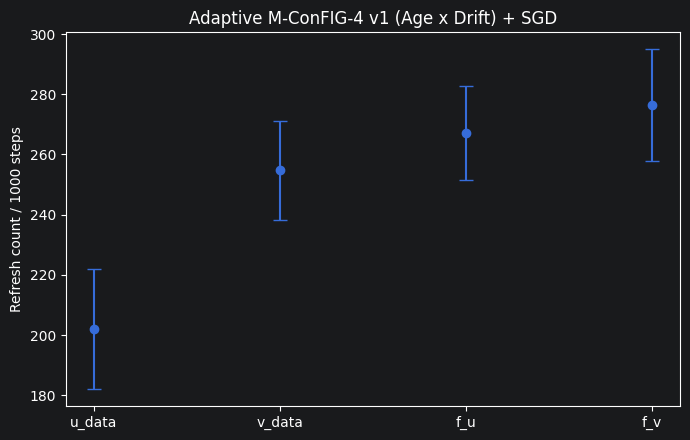

In [25]:

for method in METHODS:
    label = model_name(method)

    rows = [
        r
        for r in refresh_summary_rows
        if r["method"] == label
    ]

    if not rows:
        continue

    tasks = [r["task"] for r in rows]
    counts = [
        float(r["mean_refresh_count"])
        for r in rows
    ]
    stds = [
        0.0
        if not np.isfinite(
            float(r["std_refresh_count"])
        )
        else float(r["std_refresh_count"])
        for r in rows
    ]

    x = np.arange(len(tasks))

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        x,
        counts,
        yerr=stds,
        fmt="o",
        capsize=5,
    )
    plt.xticks(x, tasks)
    plt.ylabel("Refresh count / 1000 steps")
    plt.title(label)
    plt.tight_layout()
    plt.savefig(
        AGG_DIR
        / f"{method}_refresh_allocation.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


# 可视化：Physics Convergence

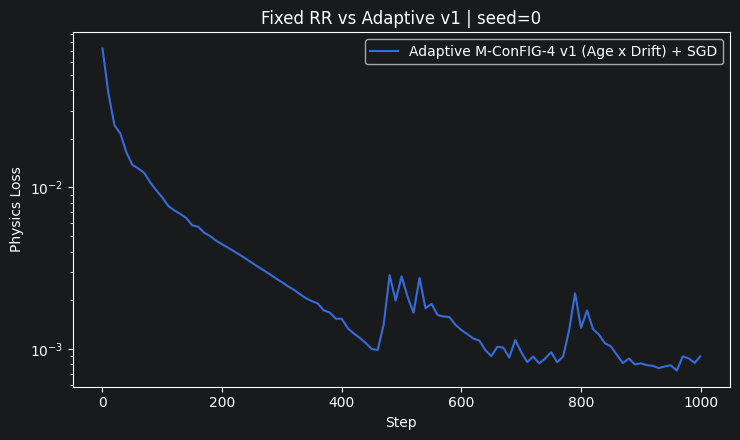

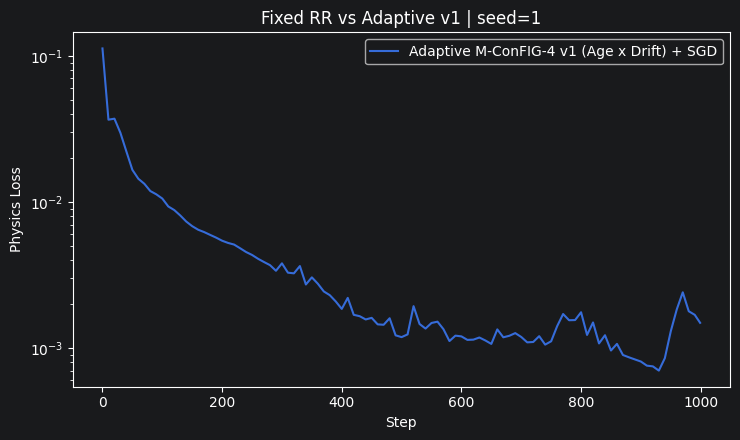

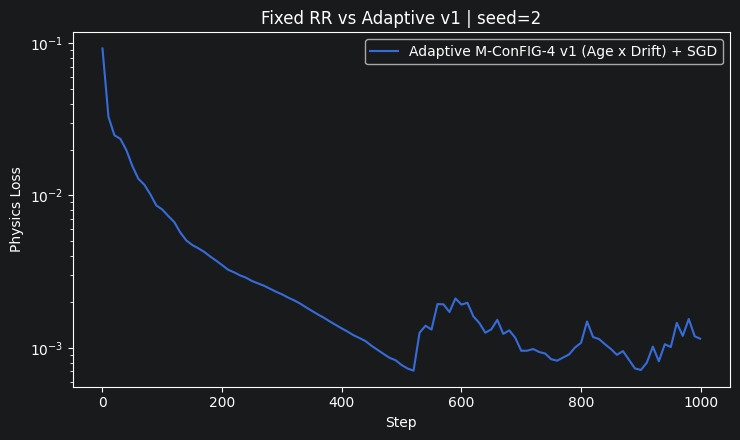

In [26]:

for seed in RUN_SEEDS:
    plt.figure(figsize=(7.5, 4.5))

    plotted = False

    for method in METHODS:
        label = model_name(method)

        rows = [
            r
            for r in all_metric_rows
            if (
                r["method"] == label
                and int(r["seed"]) == seed
            )
        ]

        if not rows:
            continue

        rows = sorted(
            rows,
            key=lambda r: int(r["step"]),
        )

        plt.semilogy(
            [int(r["step"]) for r in rows],
            [float(r["physics"]) for r in rows],
            label=label,
        )
        plotted = True

    if plotted:
        plt.xlabel("Step")
        plt.ylabel("Physics Loss")
        plt.title(
            f"Fixed RR vs Adaptive v1 | seed={seed}"
        )
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            AGG_DIR
            / f"seed_{seed}_physics_fixed_vs_adaptive.png",
            dpi=220,
            bbox_inches="tight",
        )
        plt.show()
    else:
        plt.close()


# 可视化：Adaptive 的 task 选择序列

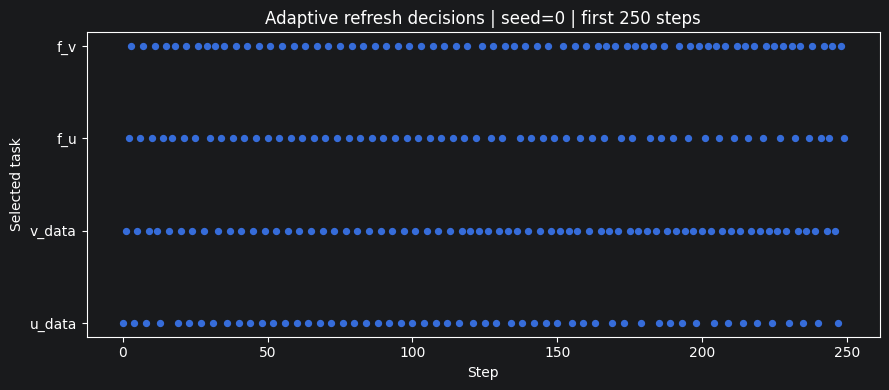

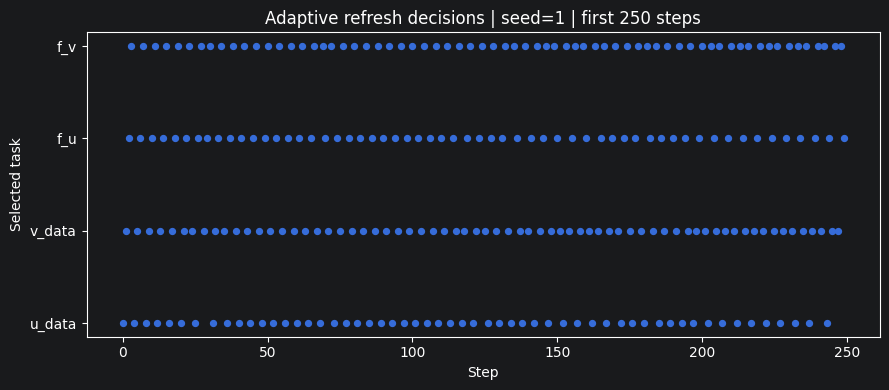

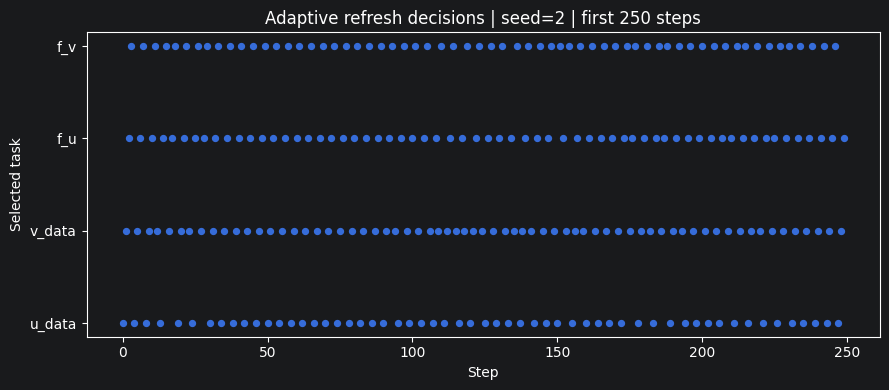

In [27]:

for seed in RUN_SEEDS:
    rows = [
        r
        for r in all_scheduler_rows
        if (
            r["method"] == adaptive_label
            and int(r["seed"]) == seed
        )
    ]

    if not rows:
        continue

    # 前 250 step 更容易观察调度结构。
    rows = [
        r
        for r in rows
        if int(r["step"]) < 250
    ]

    plt.figure(figsize=(9, 4.0))
    plt.scatter(
        [int(r["step"]) for r in rows],
        [int(r["selected_index"]) for r in rows],
        s=18,
    )
    plt.yticks(
        range(len(LOSS_KEYS)),
        LOSS_KEYS,
    )
    plt.xlabel("Step")
    plt.ylabel("Selected task")
    plt.title(
        f"Adaptive refresh decisions | seed={seed} | first 250 steps"
    )
    plt.tight_layout()
    plt.savefig(
        AGG_DIR
        / f"seed_{seed}_adaptive_selection_first250.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


# 可视化：场误差 mean ± std

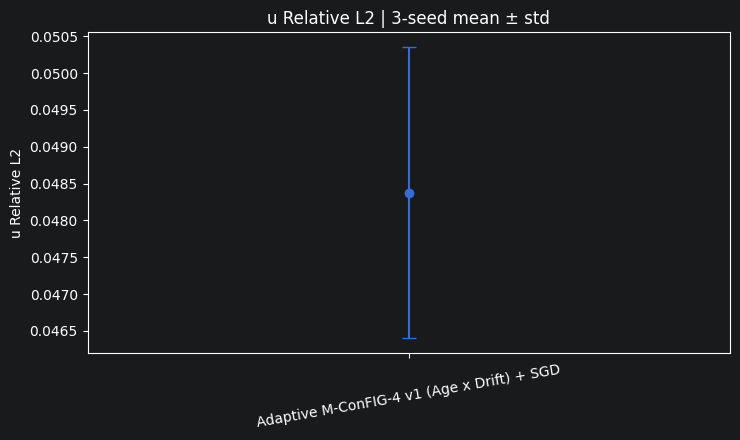

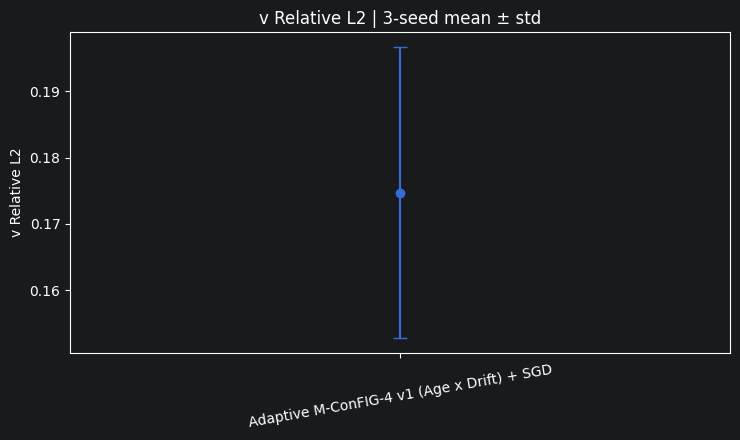

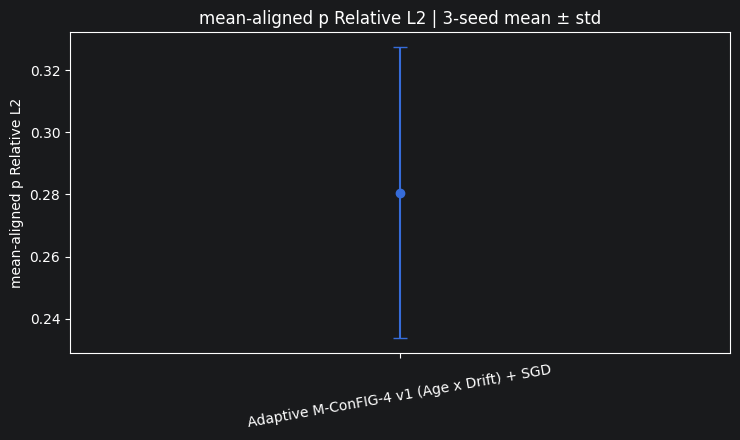

In [28]:

for metric, ylabel in [
    ("u_relative_l2", "u Relative L2"),
    ("v_relative_l2", "v Relative L2"),
    (
        "p_mean_aligned_relative_l2",
        "mean-aligned p Relative L2",
    ),
]:
    rows = [
        r
        for r in summary_rows
        if r["metric"] == metric
    ]

    if not rows:
        continue

    labels = [r["method"] for r in rows]
    means = [
        float(r["mean"])
        for r in rows
    ]
    stds = [
        0.0
        if not np.isfinite(float(r["std"]))
        else float(r["std"])
        for r in rows
    ]

    x = np.arange(len(labels))

    plt.figure(figsize=(7.5, 4.5))
    plt.errorbar(
        x,
        means,
        yerr=stds,
        fmt="o",
        capsize=5,
    )
    plt.xticks(
        x,
        labels,
        rotation=10,
    )
    plt.ylabel(ylabel)
    plt.title(
        f"{ylabel} | 3-seed mean ± std"
    )
    plt.tight_layout()
    plt.savefig(
        AGG_DIR
        / f"{metric}_fixed_vs_adaptive.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()



# 如何判断 Adaptive v1 是否值得继续

## 成功信号

第一版不要求“全面超过所有旧方法”。

最关键的是在几乎相同的 fresh-gradient budget 下：

$$
N_{\mathrm{fresh}}\approx1000
$$

Adaptive 相比 Fixed RR 出现以下组合：

```text
v error        ↓
physics loss   ↓
strict threshold 更容易达到
negative update-fresh alignment ↓
wall time 仍接近 Fixed RR
scheduler overhead 很小
```

如果成立，就说明：

> **Fixed RR 的等频刷新不是最优的计算预算分配。**

---

## 特别关注：v 和 f_v

上一轮 Fixed RR 中 $v$ 场退化最明显。

因此跑完后重点看：

```text
v_data refresh fraction
f_v refresh fraction
```

以及：

```text
v_data old-estimate/fresh cosine
f_v old-estimate/fresh cosine
```

如果 Adaptive 自动提高了 `v_data / f_v` 的刷新比例，同时 $v$ error 恢复，这是非常值得继续验证的机制线索。

但不要仅凭“刷新更多 + v 好了”就直接宣称因果，需要后续 targeted ablation。

---

## 如果 Adaptive 和 Fixed RR 基本一样

说明当前：

$$
\text{Age}\times\text{Drift}
$$

这一低成本 proxy 不足以提供额外信息。

下一步优先考虑增加一个变量：

- cached conflict；
- loss descent / plateau；
- per-task cost；

而不是直接堆很多模块。

---

## 如果 Adaptive 明显更差

先检查：

1. 是否某一 task 被过度刷新；
2. `max_age_guard` 是否频繁触发；
3. drift EMA 是否被早期噪声主导；
4. scheduler 是否产生明显的 task starvation；
5. Adaptive 的 update-fresh alignment 是否反而更差；
6. `scheduler_time_s` 是否虽然很小，但实际选择逻辑无效。

第一版失败也有研究价值：它能排除“简单 age×drift 就够了”的假设。


# 可选：读取上一轮 Full-Refresh / Fixed-RR 结果作为历史上下文

In [29]:

PREVIOUS_SUMMARY = (
    PREVIOUS_MCONFIG_ROOT
    / "aggregate"
    / "mean_std_summary.csv"
)

PREVIOUS_FIXED_VS_FULL = (
    PREVIOUS_MCONFIG_ROOT
    / "aggregate"
    / "fixed_vs_full_refresh_summary.csv"
)

if PREVIOUS_SUMMARY.exists():
    print("Previous M-ConFIG experiment summary:")
    for row in read_rows(PREVIOUS_SUMMARY):
        if row["metric"] in [
            "u_relative_l2",
            "v_relative_l2",
            "p_mean_aligned_relative_l2",
            "final_physics_loss",
            "mean_sampled_physics_loss",
            "algorithm_wall_time_est_min",
            "max_core_peak_vram_mib",
            "true_task_gradient_refreshes",
        ]:
            print(row)
else:
    print("Previous summary not found; skip.")

print()
print(
    "Primary causal comparison of THIS notebook remains: "
    "Fixed RR vs Adaptive v1."
)


Previous M-ConFIG experiment summary:
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'u_relative_l2', 'n': '3', 'mean': '0.05535574243831104', 'std': '0.011712989255438193'}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'v_relative_l2', 'n': '3', 'mean': '0.15115096044207454', 'std': '0.019584693976626516'}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'p_mean_aligned_relative_l2', 'n': '3', 'mean': '0.2809657555852594', 'std': '0.04184072531960043'}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'final_physics_loss', 'n': '3', 'mean': '0.00013778083181629577', 'std': '1.7593259578543084e-05'}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'mean_sampled_physics_loss', 'n': '3', 'mean': '0.0017735625800137601', 'std': '0.0001880684461679586'}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'algorithm_wall_time_est_min', 'n': '3', 'mean': '11.524731559460955', 'std': '0.23240252963521352'}
{'method': 'Full-Refresh PseudoM

# 输出文件

In [30]:

print(OUTPUT_ROOT.resolve())

print(
    """
Expected output:

navier_stokes_adaptive_mconfig4_v1/
├── seed_0/
│   ├── mconfig4_fixed_roundrobin/
│   │   ├── model.pt
│   │   ├── scheduler_history.csv
│   │   ├── metric_history.csv
│   │   ├── probe_history.csv
│   │   ├── refresh_counts.csv
│   │   ├── field_metrics.csv
│   │   ├── threshold_steps.csv
│   │   ├── predictions.npz
│   │   └── run_meta.json
│   └── adaptive_mconfig4_age_drift_v1/
│       └── ...
├── seed_1/
├── seed_2/
└── aggregate/
    ├── mean_std_summary.csv
    ├── threshold_mean_std.csv
    ├── refresh_allocation_summary.csv
    ├── scheduler_task_diagnostics.csv
    ├── update_fresh_alignment_summary.csv
    ├── staleness_by_task_age.csv
    ├── fixed_vs_adaptive_summary.csv
    ├── all_scheduler_history.csv
    ├── all_probe_history.csv
    └── *.png
"""
)


/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adaptive_mconfig4_v1

Expected output:

navier_stokes_adaptive_mconfig4_v1/
├── seed_0/
│   ├── mconfig4_fixed_roundrobin/
│   │   ├── model.pt
│   │   ├── scheduler_history.csv
│   │   ├── metric_history.csv
│   │   ├── probe_history.csv
│   │   ├── refresh_counts.csv
│   │   ├── field_metrics.csv
│   │   ├── threshold_steps.csv
│   │   ├── predictions.npz
│   │   └── run_meta.json
│   └── adaptive_mconfig4_age_drift_v1/
│       └── ...
├── seed_1/
├── seed_2/
└── aggregate/
    ├── mean_std_summary.csv
    ├── threshold_mean_std.csv
    ├── refresh_allocation_summary.csv
    ├── scheduler_task_diagnostics.csv
    ├── update_fresh_alignment_summary.csv
    ├── staleness_by_task_age.csv
    ├── fixed_vs_adaptive_summary.csv
    ├── all_scheduler_history.csv
    ├── all_probe_history.csv
    └── *.png




# 跑完后优先发给我这些结果

```text
aggregate/fixed_vs_adaptive_summary.csv
aggregate/mean_std_summary.csv
aggregate/threshold_mean_std.csv
aggregate/refresh_allocation_summary.csv
aggregate/scheduler_task_diagnostics.csv
aggregate/update_fresh_alignment_summary.csv
aggregate/staleness_by_task_age.csv
```

如果需要进一步定位 scheduler 行为，再补：

```text
aggregate/all_scheduler_history.csv
aggregate/all_probe_history.csv
```

下一步分析会重点回答：

$$
\boxed{
\text{相同 fresh-gradient budget 下，
Adaptive 是否把计算预算分配给了更值得刷新的 task？}
}
$$

以及：

$$
\boxed{
\text{这种分配是否真正改善了 }v\text{、physics 和 update freshness？}
}
$$
